**Tugas Individu Coding 2 - Fazari Razka Davira**

In [1]:
!pip install -q split-folders timm grad-cam

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
import timm
import cv2
import numpy as np
import shutil
import glob
import splitfolders
import matplotlib.pyplot as plt
from PIL import Image
import copy
import time
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import seaborn as sns
import random
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device("cpu")
print(f"Menggunakan device: {device}")

Menggunakan device: cpu


In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    is_colab = True
except ImportError:
    print('Running locally, skipping Google Drive mount')
    is_colab = False


Running locally, skipping Google Drive mount


In [3]:
if is_colab:
    base_path = '/content/drive/MyDrive'
    path_zip_kaggle = f'{base_path}/busi-kaggle.zip'
    path_zip_mendeley = f'{base_path}/busi-mendeley.zip'
else:
    # Local paths (placeholders as we will skip extraction)
    base_path = '../Dataset'
    path_zip_kaggle = ''
    path_zip_mendeley = ''

target_kaggle   = 'dataset_kaggle'
target_mendeley   = 'dataset_mendeley'

print("=== MEMPROSES DATASET ===")
if is_colab:
    if os.path.exists(path_zip_kaggle):
        !unzip -q "{path_zip_kaggle}" -d "{target_kaggle}"
    if os.path.exists(path_zip_mendeley):
        !unzip -q "{path_zip_mendeley}" -d "{target_mendeley}"
else:
    print("Mode Lokal: Melewati ekstraksi zip (Dataset diasumsikan sudah ada)")


=== MEMPROSES DATASET ===
Mode Lokal: Melewati ekstraksi zip (Dataset diasumsikan sudah ada)


In [4]:
path_kaggle = "dataset_kaggle/Dataset_BUSI_with_GT"
path_mendeley_root = "dataset_mendeley"

# Output Path Logic
if is_colab:
    output_path = "dataset_gabungan"
    if not os.path.exists(output_path):
        os.makedirs(output_path)
    classes = ['benign', 'malignant', 'normal']
    for c in classes:
        os.makedirs(os.path.join(output_path, c), exist_ok=True)
else:
    output_path = "../Dataset"
    print(f"Mode Lokal: output_path set to {output_path}")

# Function Definitions (Always define to safely skip)
def smart_merge_mendeley(root_folder, output_root):
    count_benign = 0
    count_malig = 0

    all_files = []
    for ext in ['*.png', '*.jpg', '*.jpeg', '*.bmp']:
        all_files.extend(glob.glob(os.path.join(root_folder, '**', ext), recursive=True))

    for f in all_files:
        filename = os.path.basename(f).lower()

        target_class = None
        if 'benign' in filename:
            target_class = 'benign'
            count_benign += 1
        elif 'malignant' in filename:
            target_class = 'malignant'
            count_malig += 1
        else:
            parent_folder = os.path.basename(os.path.dirname(f)).lower()
            if 'benign' in parent_folder:
                target_class = 'benign'
                count_benign += 1
            elif 'malignant' in parent_folder:
                target_class = 'malignant'
                count_malig += 1

        if target_class:
            dest_name = f"mendeley_{filename}"
            dest_path = os.path.join(output_root, target_class, dest_name)
            shutil.copy(f, dest_path)

    return count_benign, count_malig

def copy_kaggle_simple(src, cls, dst):
    files = glob.glob(os.path.join(src, cls, '*.*'))
    cnt = 0
    for f in files:
        if 'mask' not in os.path.basename(f):
            shutil.copy(f, os.path.join(dst, cls, f"kaggle_{os.path.basename(f)}"))
            cnt += 1
    return cnt

print("=== MULAI MERGE DATASET ===")

if is_colab:
    print("Copying Kaggle Data...")
    k_benign = copy_kaggle_simple(path_kaggle, 'benign', output_path)
    k_malig = copy_kaggle_simple(path_kaggle, 'malignant', output_path)
    k_normal = copy_kaggle_simple(path_kaggle, 'normal', output_path)

    print("Copying Mendeley Data...")
    m_benign, m_malig = smart_merge_mendeley(path_mendeley_root, output_path)
else:
    print("Mode Lokal: Melewati proses merge (Dataset diasumsikan sudah siap/merged).")
    k_benign, k_malig, k_normal = 0, 0, 0
    m_benign, m_malig = 0, 0

print("\n" + "="*40)
print(f"HASIL AKHIR PENGGABUNGAN:")
print(f"Benign   : {k_benign} (Kaggle) + {m_benign} (Mendeley) = {k_benign + m_benign}")
print(f"Malignant: {k_malig} (Kaggle) + {m_malig} (Mendeley) = {k_malig + m_malig}")
print(f"Normal   : {k_normal} (Kaggle) + 0 = {k_normal}")
print("="*40)

# Splitting
if is_colab:
    if os.path.exists("dataset_split"):
        shutil.rmtree("dataset_split")

print("Sedang membagi dataset (Splitting)...")
# output_path points to ../Dataset if local, so splitfolders works on that
splitfolders.ratio(output_path, output="dataset_split", seed=42, ratio=(.7, .15, .15), group_prefix=None) # Split Dataset (Train 70%, Val 15%, Test 15%)
print("Selesai! Dataset siap di folder 'dataset_split'")

Mode Lokal: output_path set to ../Dataset
=== MULAI MERGE DATASET ===
Mode Lokal: Melewati proses merge (Dataset diasumsikan sudah siap/merged).

HASIL AKHIR PENGGABUNGAN:
Benign   : 0 (Kaggle) + 0 (Mendeley) = 0
Malignant: 0 (Kaggle) + 0 (Mendeley) = 0
Normal   : 0 (Kaggle) + 0 = 0
Sedang membagi dataset (Splitting)...


Copying files: 1030 files [00:01, 603.34 files/s]

Selesai! Dataset siap di folder 'dataset_split'


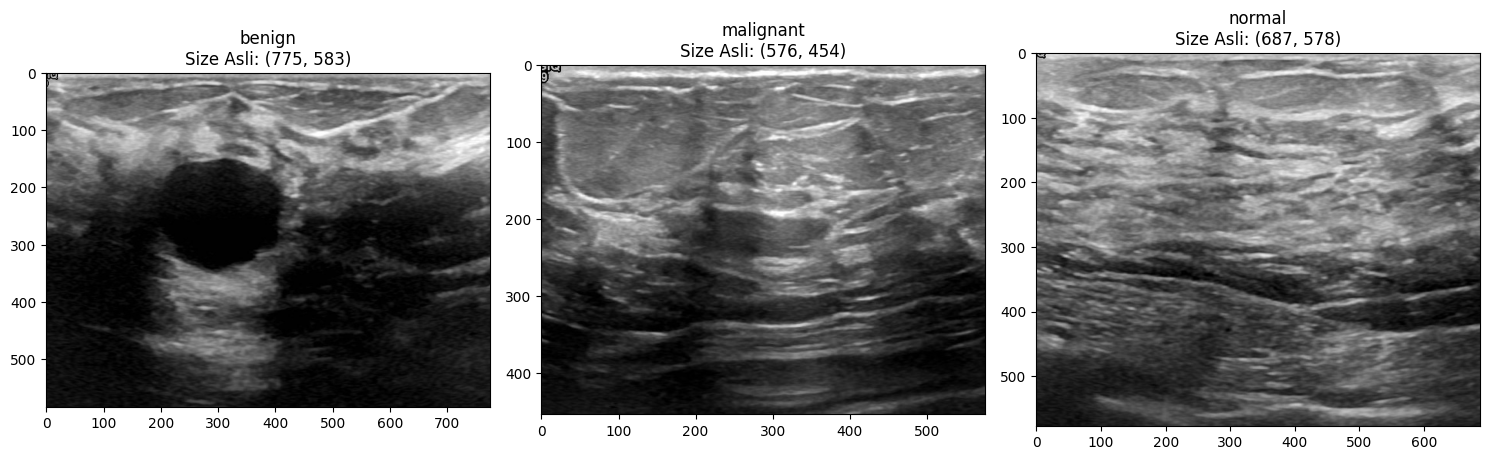

In [5]:
def show_raw_images(dataset_path, num_images=3):

    classes = ['benign', 'malignant', 'normal']

    plt.figure(figsize=(15, 5))

    for i, cls in enumerate(classes):
        class_folder = os.path.join(dataset_path, 'train', cls)
        random_img = random.choice(os.listdir(class_folder))
        img_path = os.path.join(class_folder, random_img)

        img = Image.open(img_path)

        plt.subplot(1, 3, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f"{cls}\nSize Asli: {img.size}")
        plt.axis('on')

    plt.tight_layout()
    plt.show()

show_raw_images('dataset_split')

--- Training DenseNet121 (Raw Data) ---
Ep 1: Val Acc: 0.7451
Ep 2: Val Acc: 0.8170
Ep 3: Val Acc: 0.8693
Ep 4: Val Acc: 0.8431
Ep 5: Val Acc: 0.8627
Ep 6: Val Acc: 0.8562
Ep 7: Val Acc: 0.8758
Ep 8: Val Acc: 0.8366
Ep 9: Val Acc: 0.8301
Ep 10: Val Acc: 0.8431


/home/habb/Kuliah/HUMIC/Integrated-AI/vhumic/lib/python3.12/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


--- Training Xception (Raw Data) ---
Ep 1: Val Acc: 0.6144
Ep 2: Val Acc: 0.7974
Ep 3: Val Acc: 0.8497
Ep 4: Val Acc: 0.8301
Ep 5: Val Acc: 0.8562
Ep 6: Val Acc: 0.8366
Ep 7: Val Acc: 0.8235
Ep 8: Val Acc: 0.8301
Ep 9: Val Acc: 0.8497
Ep 10: Val Acc: 0.8431


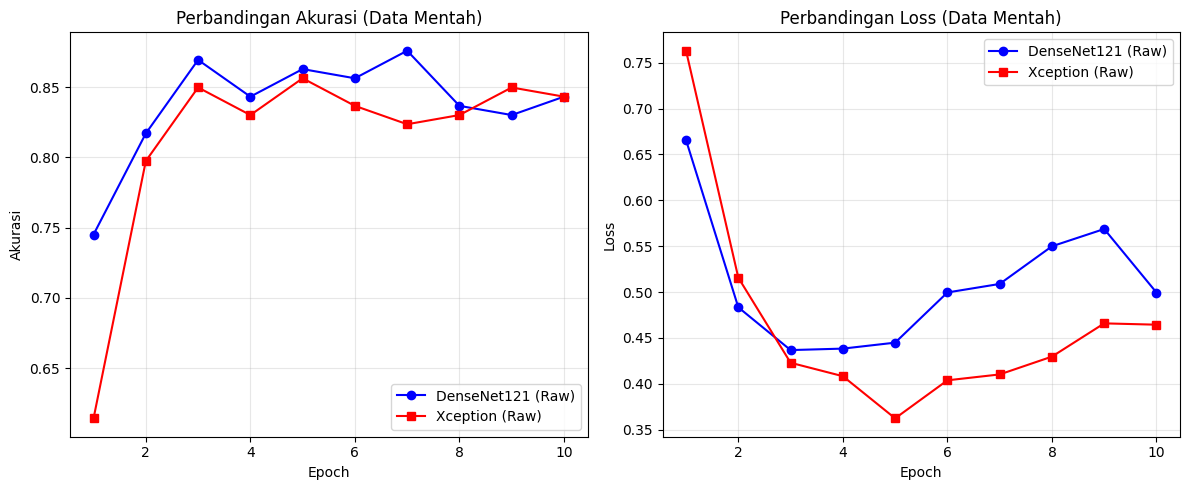

In [6]:
transform_raw = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

data_dir = 'dataset_split'
BATCH = 32

train_set_raw = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=transform_raw)
val_set_raw   = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=transform_raw)
test_set_raw  = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=transform_raw)

loader_raw = {
    'train': DataLoader(train_set_raw, batch_size=BATCH, shuffle=True),
    'val': DataLoader(val_set_raw, batch_size=BATCH, shuffle=False),
    'test': DataLoader(test_set_raw, batch_size=1, shuffle=False)
}

def train_quick(model, name, epochs=10):
    print(f"--- Training {name} (Raw Data) ---")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    history = {'acc': [], 'loss': []}

    for epoch in range(epochs):
        model.train()
        for inputs, labels in loader_raw['train']:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss, val_corrects = 0.0, 0
        with torch.no_grad():
            for inputs, labels in loader_raw['val']:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        epoch_loss = val_loss / len(val_set_raw)
        epoch_acc = val_corrects.double() / len(val_set_raw)

        history['acc'].append(epoch_acc.item())
        history['loss'].append(epoch_loss)
        print(f"Ep {epoch+1}: Val Acc: {epoch_acc:.4f}")

    return model, history

# A. DenseNet121
dense_base = models.densenet121(weights='DEFAULT')
dense_base.classifier = nn.Linear(1024, 3)
model_dense_raw, hist_dense_raw = train_quick(dense_base, "DenseNet121")

# B. Xception
xcp_base = timm.create_model('xception', pretrained=True)
xcp_base.fc = nn.Linear(2048, 3)
model_xcp_raw, hist_xcp_raw = train_quick(xcp_base, "Xception")

epochs = range(1, 11)
plt.figure(figsize=(12, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs, hist_dense_raw['acc'], 'b-o', label='DenseNet121 (Raw)')
plt.plot(epochs, hist_xcp_raw['acc'], 'r-s', label='Xception (Raw)')
plt.title('Perbandingan Akurasi (Data Mentah)')
plt.xlabel('Epoch'); plt.ylabel('Akurasi')
plt.legend(); plt.grid(True, alpha=0.3)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, hist_dense_raw['loss'], 'b-o', label='DenseNet121 (Raw)')
plt.plot(epochs, hist_xcp_raw['loss'], 'r-s', label='Xception (Raw)')
plt.title('Perbandingan Loss (Data Mentah)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

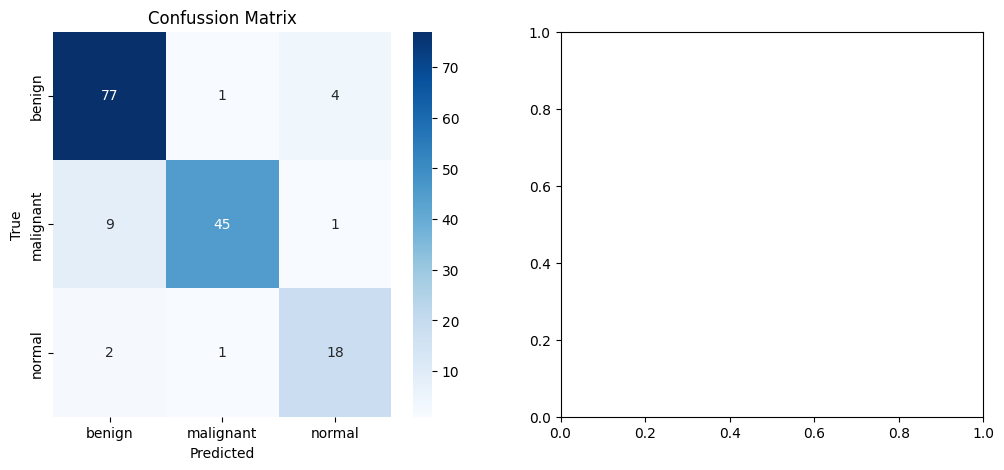

In [21]:
def show_cm(model, title, ax):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in loader_raw['test']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=train_set_raw.classes, yticklabels=train_set_raw.classes)
    ax.set_title(title); ax.set_ylabel('True'); ax.set_xlabel('Predicted')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
show_cm(model_dense_raw, "Confussion Matrix", axes[0])
plt.show()

In [8]:
class UltrasoundEnhancement(object):
    def __init__(self, apply_clahe=True, apply_denoise=True):
        self.apply_clahe = apply_clahe
        self.apply_denoise = apply_denoise

    def __call__(self, img):
        img_np = np.array(img.convert('L'))

        if self.apply_denoise:
            img_np = cv2.medianBlur(img_np, 5)

        if self.apply_clahe:
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            img_np = clahe.apply(img_np)

        img_rgb = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)

        return Image.fromarray(img_rgb)

print("Class UltrasoundEnhancement berhasil dibuat!")

Class UltrasoundEnhancement berhasil dibuat!


In [9]:
transform_dense_train = transforms.Compose([
    UltrasoundEnhancement(apply_clahe=True, apply_denoise=True),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_dense_val = transforms.Compose([
    UltrasoundEnhancement(apply_clahe=True, apply_denoise=True),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_xcp_train = transforms.Compose([
    UltrasoundEnhancement(apply_clahe=True, apply_denoise=True),
    transforms.Resize((320, 320)),
    transforms.CenterCrop(299),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

transform_xcp_val = transforms.Compose([
    UltrasoundEnhancement(apply_clahe=True, apply_denoise=True),
    transforms.Resize((320, 320)),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

data_dir = 'dataset_split'
batch_size = 32

train_set_dense = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=transform_dense_train)
val_set_dense   = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=transform_dense_val)
test_set_dense  = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=transform_dense_val)

train_loader_dense = DataLoader(train_set_dense, batch_size=batch_size, shuffle=True)
val_loader_dense   = DataLoader(val_set_dense, batch_size=batch_size, shuffle=False)
test_loader_dense  = DataLoader(test_set_dense, batch_size=1, shuffle=False)

train_set_xcp = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=transform_xcp_train)
val_set_xcp   = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=transform_xcp_val)
test_set_xcp  = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=transform_xcp_val)

train_loader_xcp = DataLoader(train_set_xcp, batch_size=batch_size, shuffle=True)
val_loader_xcp   = DataLoader(val_set_xcp, batch_size=batch_size, shuffle=False)
test_loader_xcp  = DataLoader(test_set_xcp, batch_size=1, shuffle=False)

loader_d = {
    'train': train_loader_dense,
    'val': val_loader_dense,
    'test': test_loader_dense
}

loader_x = {
    'train': train_loader_xcp,
    'val': val_loader_xcp,
    'test': test_loader_xcp
}

print(f"\nJumlah Kelas     : {len(train_set_dense.classes)} -> {train_set_dense.classes}")
print("-" * 40)
print(f"DenseNet Train   : {len(train_set_dense)} gambar ({len(train_loader_dense)} batches)")
print(f"Xception Train   : {len(train_set_xcp)} gambar ({len(train_loader_xcp)} batches)")
print("-" * 40)


Jumlah Kelas     : 3 -> ['benign', 'malignant', 'normal']
----------------------------------------
DenseNet Train   : 719 gambar (23 batches)
Xception Train   : 719 gambar (23 batches)
----------------------------------------


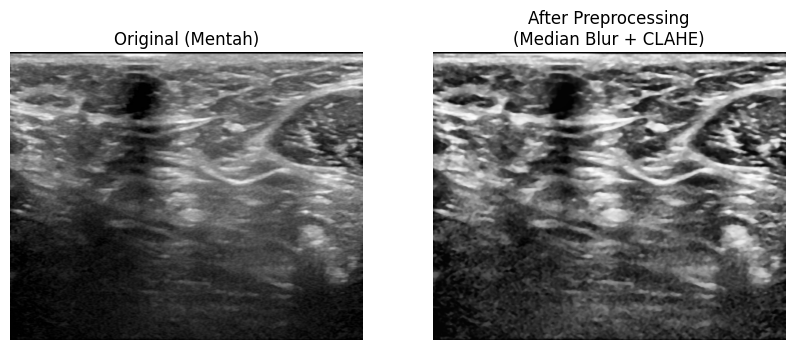

In [10]:
def show_comparison(dataset_path):
    classes = os.listdir(os.path.join(dataset_path, 'train'))
    sample_class = classes[0]
    sample_folder = os.path.join(dataset_path, 'train', sample_class)
    sample_image_path = os.path.join(sample_folder, os.listdir(sample_folder)[0])

    img_original = Image.open(sample_image_path)

    preprocessor = UltrasoundEnhancement(apply_clahe=True, apply_denoise=True)
    img_processed = preprocessor(img_original)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img_original, cmap='gray')
    plt.title("Original (Mentah)")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_processed)
    plt.title("After Preprocessing\n(Median Blur + CLAHE)")
    plt.axis('off')

    plt.show()

show_comparison('dataset_split')

In [11]:
def get_model(model_name, num_classes):
    if model_name == 'densenet':
        model = models.densenet121(weights='DEFAULT')
        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, num_classes)
    elif model_name == 'xception':
        model = timm.create_model('xception', pretrained=True)
        in_features = model.get_classifier().in_features
        model.fc = nn.Linear(in_features, num_classes)
    return model.to(device)

def train_model(model, loaders, criterion, optimizer, num_epochs=10, save_name="best.pth"):
    best_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print(f"Mulai Training {save_name}...")
    for epoch in range(num_epochs):
        for phase in ['train', 'val']:
            if phase == 'train': model.train()
            else: model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in loaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(loaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(loaders[phase].dataset)

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            if phase == 'val':
                print(f"Epoch {epoch+1}/{num_epochs} - Val Acc: {epoch_acc:.4f}")
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), save_name)

    print(f"Selesai. Best Acc: {best_acc:.4f}")
    return history

In [12]:
criterion = nn.CrossEntropyLoss()
NUM_EPOCHS = 20

print("\n=== TRAIN DENSENET121 ===")
model_dense = get_model('densenet', 3)
opt_dense = optim.Adam(model_dense.parameters(), lr=0.0001)
hist_dense = train_model(model_dense, loader_d, criterion, opt_dense, NUM_EPOCHS, "best_densenet.pth")




=== TRAIN DENSENET121 ===
Mulai Training best_densenet.pth...
Epoch 1/20 - Val Acc: 0.6732
Epoch 2/20 - Val Acc: 0.7451
Epoch 3/20 - Val Acc: 0.7516
Epoch 4/20 - Val Acc: 0.8105
Epoch 5/20 - Val Acc: 0.8170
Epoch 6/20 - Val Acc: 0.8170
Epoch 7/20 - Val Acc: 0.7843
Epoch 8/20 - Val Acc: 0.8366
Epoch 9/20 - Val Acc: 0.8301
Epoch 10/20 - Val Acc: 0.8301
Epoch 11/20 - Val Acc: 0.8301
Epoch 12/20 - Val Acc: 0.8431
Epoch 13/20 - Val Acc: 0.8235
Epoch 14/20 - Val Acc: 0.8039
Epoch 15/20 - Val Acc: 0.8497
Epoch 16/20 - Val Acc: 0.8105
Epoch 17/20 - Val Acc: 0.8301
Epoch 18/20 - Val Acc: 0.8235
Epoch 19/20 - Val Acc: 0.8301
Epoch 20/20 - Val Acc: 0.8366
Selesai. Best Acc: 0.8497



=== PERBANDINGAN 1: AKURASI VALIDASI ===


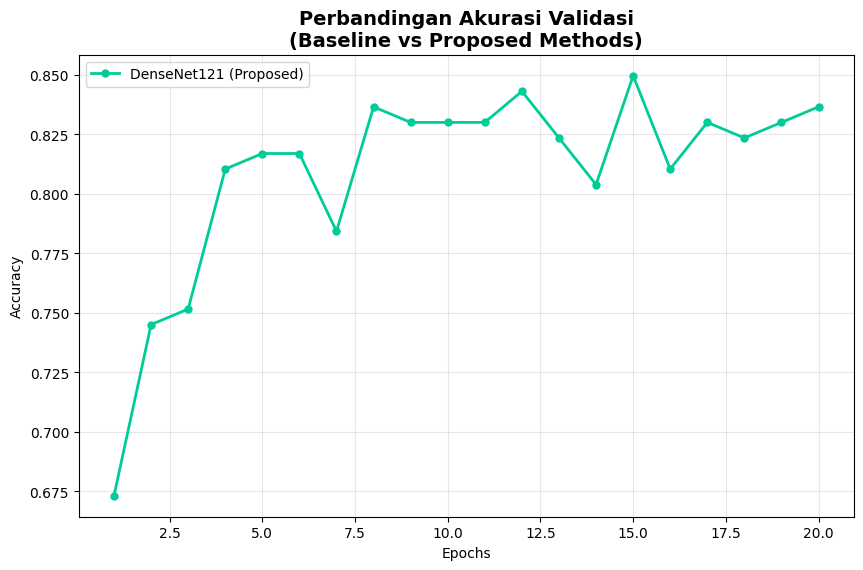


=== PERBANDINGAN 2: VALIDATION LOSS ===


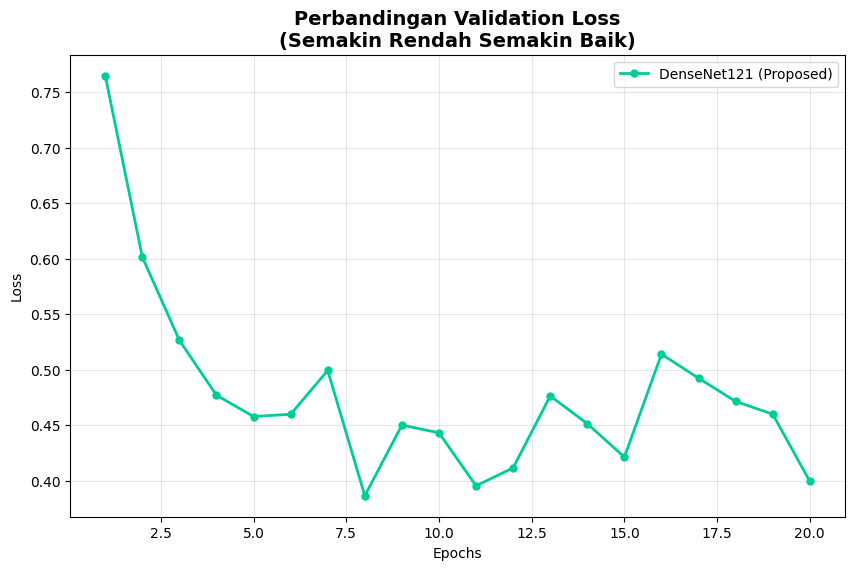

In [13]:
def plot_comparison(histories, metric, title, ylabel):
    plt.figure(figsize=(10, 6))

    colors = ['#FF9999', '#00CC99', '#9999FF']
    markers = ['--', '-', '-']

    for i, (name, history) in enumerate(histories.items()):
        if history is None:
            print(f"Warning: Data history untuk {name} tidak ditemukan. Skip.")
            continue

        val = history[metric]
        epochs = range(1, len(val) + 1)

        plt.plot(epochs, val, linestyle=markers[i%3], color=colors[i%3],
                 linewidth=2, marker='o', markersize=5, label=name)

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel(ylabel)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.show()

models_history = {
    'Baseline (No Preproc)': history_base if 'history_base' in locals() else None,
    'DenseNet121 (Proposed)': hist_dense if 'hist_dense' in locals() else None,
    'Xception (Proposed)': hist_xcp if 'hist_xcp' in locals() else None
}

print("\n=== PERBANDINGAN 1: AKURASI VALIDASI ===")
plot_comparison(
    models_history,
    metric='val_acc',
    title='Perbandingan Akurasi Validasi\n(Baseline vs Proposed Methods)',
    ylabel='Accuracy'
)

print("\n=== PERBANDINGAN 2: VALIDATION LOSS ===")
plot_comparison(
    models_history,
    metric='val_loss',
    title='Perbandingan Validation Loss\n(Semakin Rendah Semakin Baik)',
    ylabel='Loss'
)

Found 3 manual images to process.
Processing manual image: ../Dataset/benign/benign (2).png


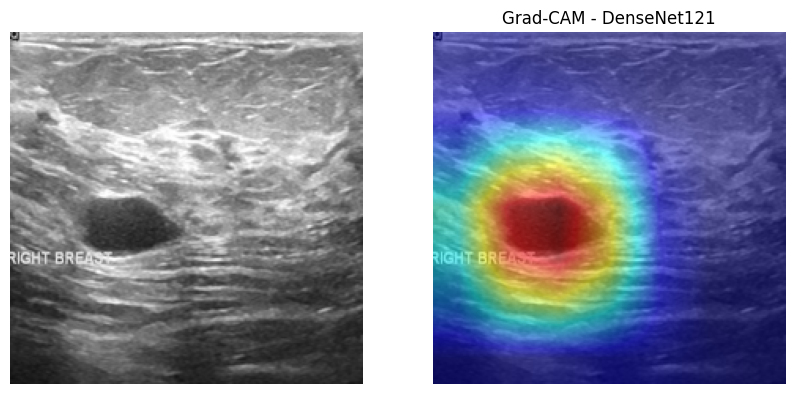

Processing manual image: ../Dataset/malignant/malignant (4).png


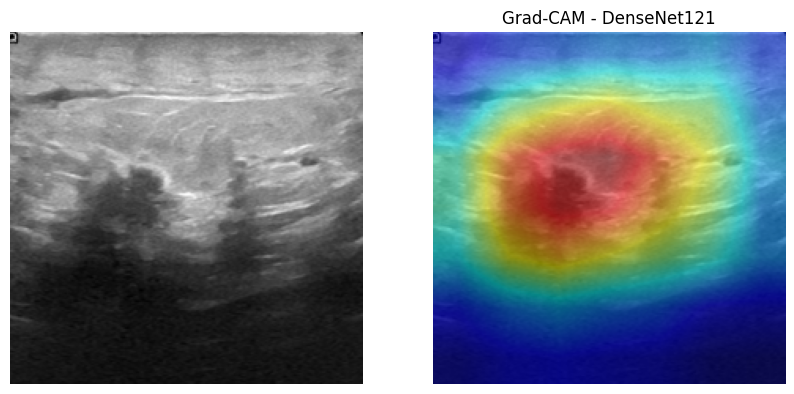

Processing manual image: ../Dataset/normal/normal (4).png


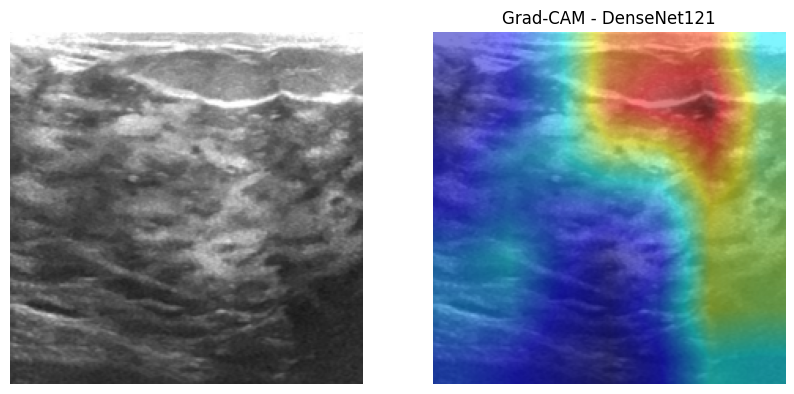

In [20]:
# Grad-CAM Visualization with Manual Path Support
import PIL.Image
import cv2
import numpy as np
import torch
from torchvision import transforms
import matplotlib.pyplot as plt
import os
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# --- PREPARE VARIABLES ---
try:
    model = model_dense
    class_names = train_set_dense.classes
    # Try to find a test dataset. If dataset_test exists (from previous cells?), use it.
    # Otherwise use test_set_dense
    if 'test_set_dense' in locals():
        dataset_test = test_set_dense
    elif 'loader_d' in locals():
        dataset_test = loader_d['test'].dataset
    else:
        # Fallback if neither exists (unlikely if run linearly)
        print("Warning: Could not automatically determine test dataset. visualize_gradcam_fixed might fail.")
        dataset_test = [] 
except NameError:
    print("Warning: model_dense or train_set_dense not defined. Ensure previous cells are run.")
    model = None
    class_names = []
    dataset_test = []

# --- USER CONFIGURATION ---
# Enter paths to your test images here.
test_image_paths = [
    '../Dataset/benign/benign (2).png',
    '../Dataset/malignant/malignant (4).png',
    '../Dataset/normal/normal (4).png'
]
# --------------------------

def get_target_layers(model):
    if hasattr(model, 'features'): return [model.features[-1]]
    if hasattr(model, 'blocks'): return [model.blocks[-1]]
    if hasattr(model, 'conv_head'): return [model.conv_head]
    # Fallback search
    last_conv = None
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Conv2d):
            last_conv = module
    if last_conv: return [last_conv]
    raise AttributeError("Could not find a suitable target layer for Grad-CAM")

def predict_single_image_gradcam(model, image_path, class_names):
    print(f"Processing manual image: {image_path}")
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    try:
        if not os.path.exists(image_path):
            print(f"Error: Image not found at {image_path}")
            return
            
        image = PIL.Image.open(image_path).convert('RGB')
        input_tensor = transform(image).unsqueeze(0).to(device)
        
        model.eval()
        target_layers = get_target_layers(model)
        cam = GradCAM(model=model, target_layers=target_layers)
        grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
        
        # Prediction
        with torch.no_grad():
            outputs = model(input_tensor)
            prob = torch.nn.functional.softmax(outputs, dim=1)
            score, preds = torch.max(prob, 1)
            predicted_label = class_names[preds[0]]
            confidence = score.item()
            
        # Visualization
        img_display = np.array(image.resize((224, 224))) / 255.0
        visualization = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)
        
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        ax[0].imshow(img_display)
        ax[0].axis('off')
        
        ax[1].imshow(visualization)
        ax[1].set_title("Grad-CAM - DenseNet121")
        ax[1].axis('off')
        plt.show()
        
    except Exception as e:
        print(f"Error processing manual image: {e}")
        import traceback
        traceback.print_exc()

def visualize_gradcam_fixed(model, test_dataset, class_names):
    model.eval()
    try:
       target_layers = get_target_layers(model)
    except AttributeError as e:
       print(e); return

    class_indices = {}
    # Try to find one example per class
    for idx in range(len(test_dataset)):
        try:
            _, label = test_dataset[idx]
            class_name = class_names[label]
            if class_name not in class_indices:
                class_indices[class_name] = idx
            if len(class_indices) == len(class_names):
                break
        except:
             continue
            
    count = len(class_indices)
    if count == 0:
        print("No examples found in test dataset.")
        return

    fig = plt.figure(figsize=(15, 5 * count))
    
    for i, (class_name, idx) in enumerate(class_indices.items()):
        image, label = test_dataset[idx]
        input_tensor = image.unsqueeze(0).to(device)
        cam = GradCAM(model=model, target_layers=target_layers)
        grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
        
        # Denormalize
        img_display = image.permute(1, 2, 0).cpu().numpy()
        img_display = (img_display * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
        img_display = np.clip(img_display, 0, 1)
        visualization = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)

        ax = fig.add_subplot(count, 2, 2*i + 1)
        ax.imshow(img_display)
        ax.set_title(f"Original: {class_name}")
        ax.axis('off')
        ax = fig.add_subplot(count, 2, 2*i + 2)
        ax.imshow(visualization)
        ax.set_title(f"Grad-CAM: {class_name}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# --- Execution Logic ---
manual_images_processed = False
if 'test_image_paths' in locals() and test_image_paths:
    print(f"Found {len(test_image_paths)} manual images to process.")
    for img_path in test_image_paths:
        if img_path: # Skip empty strings
            predict_single_image_gradcam(model, img_path, class_names)
            manual_images_processed = True

if not manual_images_processed:
    print("No manual images found/processed. Generating Grad-CAM for fixed examples from dataset...")
    if 'dataset_test' in locals() and dataset_test:
        visualize_gradcam_fixed(model, dataset_test, class_names)
    else:
        print("Error: Test dataset not found.")
